# Assignment No. 5 — Generative AI (AI4009)
## Vision Language Model (VLM) Fine-Tuning with QLoRA for Document-to-Markdown Generation
**Model:** Qwen2-VL-2B-Instruct | **Platform:** Kaggle T4×2 | **Technique:** QLoRA (4-bit)

## Step 0 — Install Dependencies

In [1]:
import subprocess, sys

packages = [
    "transformers>=4.45.0",
    "peft>=0.12.0",
    "bitsandbytes>=0.43.0",
    "accelerate>=0.34.0",
    "datasets>=2.20.0",
    "qwen-vl-utils",
    "pillow",
    "tqdm",
    "gradio",
    "evaluate",
    "rouge_score",
    "matplotlib",
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("All packages installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.4 MB/s eta 0:00:00
All packages installed.


## Step 1 — Imports & Configuration

In [6]:
# ── Reproducibility ──────────────────────────────────────────────────────────
import os, gc, json, random, warnings
import numpy as np
import torch
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm import tqdm
warnings.filterwarnings("ignore")

# ── HuggingFace / PEFT ──────────────────────────────────────────────────────
from transformers import (
    Qwen2VLForConditionalGeneration,
    AutoProcessor,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from peft import LoraConfig, get_peft_model, TaskType, prepare_model_for_kbit_training
from datasets import load_dataset, Dataset
from torch.utils.data import DataLoader
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# ── GPU check ────────────────────────────────────────────────────────────────
NUM_GPUS = torch.cuda.device_count()
DEVICE   = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE} | GPUs available: {NUM_GPUS}")
for i in range(NUM_GPUS):
    props = torch.cuda.get_device_properties(i)
    print(f"  GPU {i}: {props.name}  {props.total_memory/1e9:.1f} GB")

# ── Hyper-parameters — tuned for T4×2, <2 hr wall time ──────────────────────
CFG = dict(
    model_id        = "Qwen/Qwen2-VL-2B-Instruct",
    max_samples     = 300,   # 240 train + 60 val → ~240 opt steps per epoch
    train_ratio     = 0.80,
    image_size      = 448,   # slightly smaller → faster encode, less VRAM
    max_new_tokens  = 384,
    max_seq_len     = 768,   # shorter context → faster
    batch_size      = 1,
    grad_accum      = 4,     # effective batch = 4
    epochs          = 1,     # 1 epoch, optionally bump to 2
    lr              = 2e-4,
    lora_r          = 8,     # smaller rank → fewer params → faster
    lora_alpha      = 16,
    lora_dropout    = 0.05,
    output_dir      = "/kaggle/working/vlm_qlora",
)
os.makedirs(CFG["output_dir"], exist_ok=True)

# ── Rough time estimate ───────────────────────────────────────────────────────
# 300 samples × 80% = 240 train  /  grad_accum=4  → 60 optimizer steps/epoch
# T4 ~25-35 s/step with image+text → ~60×30s = ~30 min/epoch
# 1 epoch ≈ 30 min   |   2 epochs ≈ 60 min   (well within 2 hr)
print("Config:", json.dumps({k:v for k,v in CFG.items() if k!='output_dir'}, indent=2))


Device: cuda | GPUs available: 2
  GPU 0: Tesla T4  15.6 GB
  GPU 1: Tesla T4  15.6 GB
Config: {
  "model_id": "Qwen/Qwen2-VL-2B-Instruct",
  "max_samples": 300,
  "train_ratio": 0.8,
  "image_size": 448,
  "max_new_tokens": 384,
  "max_seq_len": 768,
  "batch_size": 1,
  "grad_accum": 4,
  "epochs": 1,
  "lr": 0.0002,
  "lora_r": 8,
  "lora_alpha": 16,
  "lora_dropout": 0.05
}


## Part 1 — Dataset Exploration

In [7]:
DATASET_PATH = Path("/kaggle/input/datasets/zphilip/nougat-training-dataset-example")

def load_nougat_dataset(root: Path):
    """Walk the nested nougat directory, pair every .png with its .mmd,
    and silently skip any corrupt / unreadable images."""
    from PIL import UnidentifiedImageError
    samples, skipped = [], 0
    png_files = sorted(root.rglob("*.png"))
    print(f"Found {len(png_files)} PNG files under {root}")

    for png_path in png_files:
        # find matching markdown
        mmd_path = png_path.with_suffix(".mmd")
        if not mmd_path.exists():
            mmd_path = png_path.with_suffix(".txt")
        if not mmd_path.exists():
            skipped += 1
            continue

        # verify image is readable before adding
        try:
            with Image.open(png_path) as img:
                img.verify()   # lightweight check — no full decode
        except Exception:
            skipped += 1
            continue

        # skip empty markdown files
        try:
            if mmd_path.stat().st_size < 5:
                skipped += 1
                continue
        except Exception:
            skipped += 1
            continue

        samples.append({"image_path": str(png_path), "markdown_path": str(mmd_path)})

    print(f"Valid pairs: {len(samples)}  |  Skipped (corrupt/missing): {skipped}")
    return samples

raw_pairs = load_nougat_dataset(DATASET_PATH)

print("\nDirectory listing (first 30 files):")
for f in sorted(DATASET_PATH.rglob("*"))[:30]:
    print(" ", f.relative_to(DATASET_PATH))


Found 14236 PNG files under /kaggle/input/datasets/zphilip/nougat-training-dataset-example
Valid pairs: 14195  |  Skipped (corrupt/missing): 41

Directory listing (first 30 files):
  0508
  0508/astro-ph0508001
  0508/astro-ph0508001/01.mmd
  0508/astro-ph0508001/01.png
  0508/astro-ph0508001/02.mmd
  0508/astro-ph0508001/02.png
  0508/astro-ph0508001/03.mmd
  0508/astro-ph0508001/03.png
  0508/astro-ph0508001/04.mmd
  0508/astro-ph0508001/04.png
  0508/astro-ph0508001/05.mmd
  0508/astro-ph0508001/05.png
  0508/astro-ph0508001/06.mmd
  0508/astro-ph0508001/06.png
  0508/astro-ph0508001/07.mmd
  0508/astro-ph0508001/07.png
  0508/astro-ph0508001/08.mmd
  0508/astro-ph0508001/08.png
  0508/astro-ph0508001/09.mmd
  0508/astro-ph0508001/09.png
  0508/astro-ph0508001/10.mmd
  0508/astro-ph0508001/10.png
  0508/astro-ph0508001/11.mmd
  0508/astro-ph0508001/11.png
  0508/astro-ph0508001/12.mmd
  0508/astro-ph0508001/12.png
  0508/astro-ph0508001/13.mmd
  0508/astro-ph0508001/13.png
  0508/as

In [9]:
# ── Inspect first few samples ─────────────────────────────────────────────────
print(f"Total pairs found: {len(raw_pairs)}")
for i, pair in enumerate(raw_pairs[:3]):
    img  = Image.open(pair["image_path"])
    with open(pair["markdown_path"], "r", encoding="utf-8", errors="ignore") as f:
        md = f.read()
    print(f"\nSample {i}:")
    print(f"  Image : {pair['image_path']} | size={img.size} mode={img.mode}")
    print(f"  MD len: {len(md)} chars")
    print(f"  MD preview: {md[:200]}")

Total pairs found: 14195

Sample 0:
  Image : /kaggle/input/datasets/zphilip/nougat-training-dataset-example/0508/astro-ph0508001/01.png | size=(816, 1056) mode=RGB
  MD len: 2522 chars
  MD preview: # Globular Clusters in Virgo Ellipticals: Unexpected Results for Giants, Dwarfs, and Nuclei from ACS Imaging

Jay Strader, Jean P. Brodie, Lee Spitler, Michael A. Beasley

UCO/Lick Observatory, Univer

Sample 1:
  Image : /kaggle/input/datasets/zphilip/nougat-training-dataset-example/0508/astro-ph0508001/02.png | size=(816, 1056) mode=RGB
  MD len: 2777 chars
  MD preview: function (GCLF) is the same for both gEs and dEs. This is contrary to expectations of dynamical friction on massive GCs, unless the primordial GCLF varies between gEs and dEs. Among gEs the GCLF turno

Sample 2:
  Image : /kaggle/input/datasets/zphilip/nougat-training-dataset-example/0508/astro-ph0508001/03.png | size=(816, 1056) mode=RGB
  MD len: 2919 chars
  MD preview: the GC systems of nucleated and non-nucleated dE

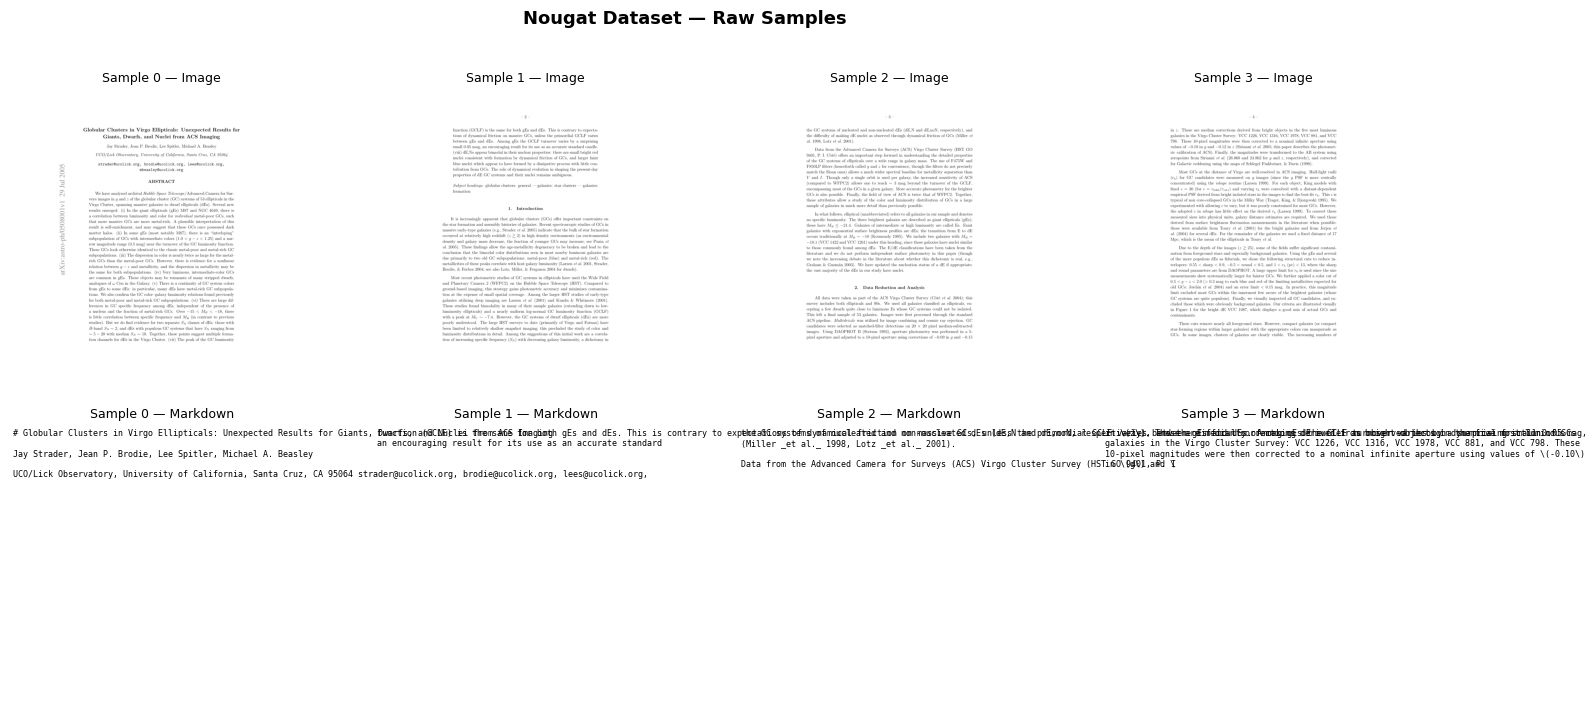

Exploration figure saved.


In [10]:
# ── Visualise 4 raw samples ───────────────────────────────────────────────────
n_show = min(4, len(raw_pairs))
fig, axes = plt.subplots(2, n_show, figsize=(18, 8))
if n_show == 1:
    axes = axes.reshape(2, 1)

for i in range(n_show):
    img = Image.open(raw_pairs[i]["image_path"]).convert("RGB")
    with open(raw_pairs[i]["markdown_path"], "r", encoding="utf-8", errors="ignore") as f:
        md_text = f.read()[:300]

    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Sample {i} — Image", fontsize=9)
    axes[0, i].axis("off")

    axes[1, i].text(0.01, 0.99, md_text, va="top", ha="left",
                    fontsize=6, family="monospace", wrap=True,
                    transform=axes[1, i].transAxes)
    axes[1, i].set_title(f"Sample {i} — Markdown", fontsize=9)
    axes[1, i].axis("off")

plt.suptitle("Nougat Dataset — Raw Samples", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/dataset_exploration.png", dpi=120)
plt.show()
print("Exploration figure saved.")

## Part 2 — Data Preparation (ChatML Format)

In [11]:
INSTRUCTION = (
    "You are a document understanding assistant. "
    "Convert the given document image into clean, structured Markdown. "
    "Preserve headings, lists, tables, equations, and code blocks. "
    "Do not add any explanation — output only the Markdown."
)

def to_chatml(pair):
    """Convert a raw file-path pair into a ChatML-style dict.
    Returns None if the image cannot be opened (corrupt files)."""
    try:
        # Image.open after verify() needs a fresh open (verify closes the file)
        img = Image.open(pair["image_path"]).convert("RGB").resize(
            (CFG["image_size"], CFG["image_size"]), Image.LANCZOS
        )
    except Exception as e:
        return None  # silently skip

    try:
        with open(pair["markdown_path"], "r", encoding="utf-8", errors="ignore") as f:
            md = f.read().strip()
        if not md:
            return None  # skip empty targets
    except Exception:
        return None

    return {
        "image"      : img,
        "instruction": INSTRUCTION,
        "target"     : md,
    }

# ── Subset ─────────────────────────────────────────────────────────────────
total   = min(CFG["max_samples"], len(raw_pairs))
indices = random.sample(range(len(raw_pairs)), total)

subset = []
for i in tqdm(indices, desc="Preparing samples"):
    result = to_chatml(raw_pairs[i])
    if result is not None:
        subset.append(result)

print(f"\nSubset size (after filtering): {len(subset)}")
print("Sample keys:", list(subset[0].keys()))
print("Image size :", subset[0]["image"].size)
print("Target snippet:", subset[0]["target"][:200])


Preparing samples: 100%|██████████| 300/300 [00:09<00:00, 32.99it/s]


Subset size (after filtering): 300
Sample keys: ['image', 'instruction', 'target']
Image size : (448, 448)
Target snippet: # AN INEQUALITY OF HADAMARD TYPE FOR PERMANENTS

 Eric Carlen\({}^{1}\), Michael Loss\({}^{1}\) Elliott H. Lieb\({}^{2}\)

\(1.\) School of Mathematics, Georgia Tech, Atlanta, GA 30332

\(2.\) Departm


## Part 3 — Train / Validation Split

In [13]:
random.shuffle(subset)
split_idx  = int(len(subset) * CFG["train_ratio"])
train_data = subset[:split_idx]
val_data   = subset[split_idx:]

print(f"Train samples : {len(train_data)}")
print(f"Val   samples : {len(val_data)}")

Train samples : 240
Val   samples : 60


## Part 4 — Load Model + QLoRA Fine-Tuning

In [14]:
# ── 4-bit quantisation config ─────────────────────────────────────────────────
bnb_config = BitsAndBytesConfig(
    load_in_4bit               = True,
    bnb_4bit_use_double_quant  = True,
    bnb_4bit_quant_type        = "nf4",
    bnb_4bit_compute_dtype     = torch.bfloat16,
)

print("Loading processor...")
processor = AutoProcessor.from_pretrained(
    CFG["model_id"],
    trust_remote_code=True,
    min_pixels=256*28*28,
    max_pixels=512*28*28,
)

print("Loading model in 4-bit...")
model = Qwen2VLForConditionalGeneration.from_pretrained(
    CFG["model_id"],
    quantization_config = bnb_config,
    device_map          = "auto",
    trust_remote_code   = True,
    torch_dtype         = torch.bfloat16,
)
model.config.use_cache = False

print("Preparing model for k-bit training...")
model = prepare_model_for_kbit_training(model)

# ── LoRA configuration ────────────────────────────────────────────────────────
# Target the attention and MLP projection layers
lora_target_modules = [
    "q_proj", "v_proj",  # attention only — fewer params, faster training
]

lora_config = LoraConfig(
    r              = CFG["lora_r"],
    lora_alpha     = CFG["lora_alpha"],
    lora_dropout   = CFG["lora_dropout"],
    target_modules = lora_target_modules,
    bias           = "none",
    task_type      = TaskType.CAUSAL_LM,
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()


Loading processor...


preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

Preparing model for k-bit training...
trainable params: 1,089,536 || all params: 2,210,075,136 || trainable%: 0.0493


In [16]:
# ── Collator ──────────────────────────────────────────────────────────────────
def build_messages(sample, include_response=True):
    """Build Qwen2-VL conversation format."""
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": sample["image"]},
                {"type": "text",  "text" : sample["instruction"]},
            ],
        }
    ]
    if include_response:
        messages.append({"role": "assistant", "content": sample["target"]})
    return messages


def collate_fn(batch):
    texts, images = [], []
    for sample in batch:
        messages = build_messages(sample, include_response=True)
        text = processor.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=False
        )
        texts.append(text)
        images.append([sample["image"]])

    inputs = processor(
        text   = texts,
        images = images,
        return_tensors = "pt",
        padding        = True,
        truncation     = True,
        max_length     = CFG["max_seq_len"],
    )

    # Labels: mask padding & image tokens
    labels = inputs["input_ids"].clone()
    labels[labels == processor.tokenizer.pad_token_id] = -100
    # mask image token id if present
    img_token_id = getattr(processor, "image_token_id", None)
    if img_token_id is not None:
        labels[labels == img_token_id] = -100

    inputs["labels"] = labels
    return inputs


# quick collation test
test_batch = collate_fn([train_data[0]])
print("Batch keys      :", list(test_batch.keys()))
print("input_ids shape :", test_batch["input_ids"].shape)
print("labels shape    :", test_batch["labels"].shape)

Batch keys      : ['input_ids', 'attention_mask', 'pixel_values', 'image_grid_thw', 'labels']
input_ids shape : torch.Size([1, 768])
labels shape    : torch.Size([1, 768])


In [17]:
# ── Custom Dataset wrapper ────────────────────────────────────────────────────
from torch.utils.data import Dataset as TorchDataset

class VLMDataset(TorchDataset):
    def __init__(self, data): self.data = data
    def __len__(self):        return len(self.data)
    def __getitem__(self, i): return self.data[i]

train_dataset = VLMDataset(train_data)
val_dataset   = VLMDataset(val_data)

print(f"Train dataset: {len(train_dataset)} | Val dataset: {len(val_dataset)}")

Train dataset: 240 | Val dataset: 60


In [18]:
# ── Training arguments ────────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir                  = CFG["output_dir"],
    num_train_epochs            = CFG["epochs"],
    per_device_train_batch_size = CFG["batch_size"],
    per_device_eval_batch_size  = CFG["batch_size"],
    gradient_accumulation_steps = CFG["grad_accum"],
    learning_rate               = CFG["lr"],
    lr_scheduler_type           = "cosine",
    warmup_ratio                = 0.05,
    weight_decay                = 0.01,
    bf16                        = True,
    fp16                        = False,
    logging_steps               = 5,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    save_total_limit            = 1,          # only keep best checkpoint
    load_best_model_at_end      = True,
    metric_for_best_model       = "eval_loss",
    greater_is_better           = False,
    report_to                   = "none",
    remove_unused_columns       = False,
    dataloader_num_workers      = 4,
    ddp_find_unused_parameters  = False,
    gradient_checkpointing      = True,
    optim                       = "paged_adamw_8bit",
    max_grad_norm               = 1.0,
    # Speed: skip eval on tiny val set if it slows things down
    dataloader_pin_memory       = True,
    torch_compile               = False,   # keep off for stability on Kaggle
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = val_dataset,
    data_collator   = collate_fn,
    # No early stopping for 1-epoch run
)

print("Trainer ready.")
total_steps = (len(train_dataset) // (CFG['batch_size'] * CFG['grad_accum'])) * CFG['epochs']
print(f"Estimated optimiser steps: {total_steps}")


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Trainer ready.
Estimated optimiser steps: 60


In [19]:
# ── TRAIN ─────────────────────────────────────────────────────────────────────
train_result = trainer.train()
print("Training complete.")
print(train_result.metrics)

# Save adapter weights
model.save_pretrained(f"{CFG['output_dir']}/lora_adapter")
processor.save_pretrained(f"{CFG['output_dir']}/lora_adapter")
print("Adapter saved.")

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Epoch,Training Loss,Validation Loss
1,0.659264,0.723532


Training complete.
{'train_runtime': 1498.4261, 'train_samples_per_second': 0.16, 'train_steps_per_second': 0.04, 'total_flos': 2117924897679360.0, 'train_loss': 0.8674798885981242, 'epoch': 1.0}
Adapter saved.


## Fine-Tuning Results — Loss Curves

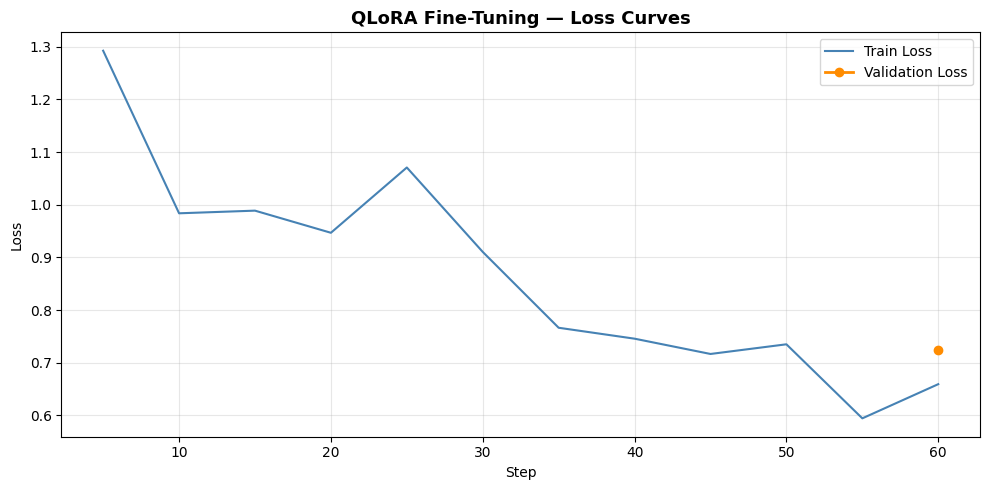

Final train loss : 0.6593
Final val   loss : 0.7235


In [20]:
log_history = trainer.state.log_history

train_steps, train_losses = [], []
val_steps,   val_losses   = [], []

for entry in log_history:
    if "loss" in entry and "eval_loss" not in entry:
        train_steps.append(entry["step"])
        train_losses.append(entry["loss"])
    if "eval_loss" in entry:
        val_steps.append(entry["step"])
        val_losses.append(entry["eval_loss"])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_steps, train_losses, label="Train Loss",      color="steelblue",  linewidth=1.5)
ax.plot(val_steps,   val_losses,   label="Validation Loss", color="darkorange", linewidth=2, marker="o")
ax.set_xlabel("Step");  ax.set_ylabel("Loss")
ax.set_title("QLoRA Fine-Tuning — Loss Curves", fontsize=13, fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/loss_curves.png", dpi=120)
plt.show()

print(f"Final train loss : {train_losses[-1]:.4f}")
print(f"Final val   loss : {val_losses[-1]:.4f}")

## Part 5 — Markdown Generation (Inference Helper)

In [21]:
model.eval()

def generate_markdown(sample, model, processor, max_new_tokens=CFG["max_new_tokens"]):
    """Run inference on a single sample and return predicted markdown."""
    messages = build_messages(sample, include_response=False)
    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = processor(
        text   = [text],
        images = [[sample["image"]]],
        return_tensors = "pt",
    ).to(model.device)

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens = max_new_tokens,
            do_sample      = False,
            temperature    = 1.0,
            repetition_penalty = 1.1,
        )

    # Decode only newly generated tokens
    input_len = inputs["input_ids"].shape[1]
    new_ids   = generated_ids[:, input_len:]
    return processor.batch_decode(new_ids, skip_special_tokens=True)[0].strip()


print("Inference function defined.")

Inference function defined.


## Part 5 — Validation Set Evaluation

In [22]:
import evaluate
rouge = evaluate.load("rouge")

# Evaluate on first 20 validation samples to save time
EVAL_LIMIT = min(20, len(val_data))
predictions, references = [], []

for i in tqdm(range(EVAL_LIMIT), desc="Validating"):
    pred = generate_markdown(val_data[i], model, processor)
    ref  = val_data[i]["target"]
    predictions.append(pred)
    references.append(ref)

rouge_scores = rouge.compute(predictions=predictions, references=references)
print("\n=== ROUGE Scores (Validation) ===")
for k, v in rouge_scores.items():
    print(f"  {k}: {v:.4f}")


Validating:   0%|          | 0/20 [00:00<?, ?it/s]The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.

Validating: 100%|██████████| 20/20 [13:16<00:00, 39.83s/it]



=== ROUGE Scores (Validation) ===
  rouge1: 0.5887
  rouge2: 0.4921
  rougeL: 0.5400
  rougeLsum: 0.5796


## Part 6 — Testing Task: 3 Training + 3 Unseen Images

In [23]:
# ── 3 training samples ────────────────────────────────────────────────────────
train_test_samples = random.sample(train_data, 3)

# ── 3 unseen samples: raw_pairs beyond the sampled subset ─────────────────────
used_indices = set(indices)  # indices used in subset
unseen_pool  = [i for i in range(len(raw_pairs)) if i not in used_indices]

if len(unseen_pool) >= 3:
    unseen_indices = random.sample(unseen_pool, 3)
    unseen_samples = [to_chatml(raw_pairs[i]) for i in unseen_indices]
else:
    # fallback: use val samples
    unseen_samples = random.sample(val_data, 3)

print(f"Train test samples : {len(train_test_samples)}")
print(f"Unseen samples     : {len(unseen_samples)}")


Train test samples : 3
Unseen samples     : 3


=== Training Images ===


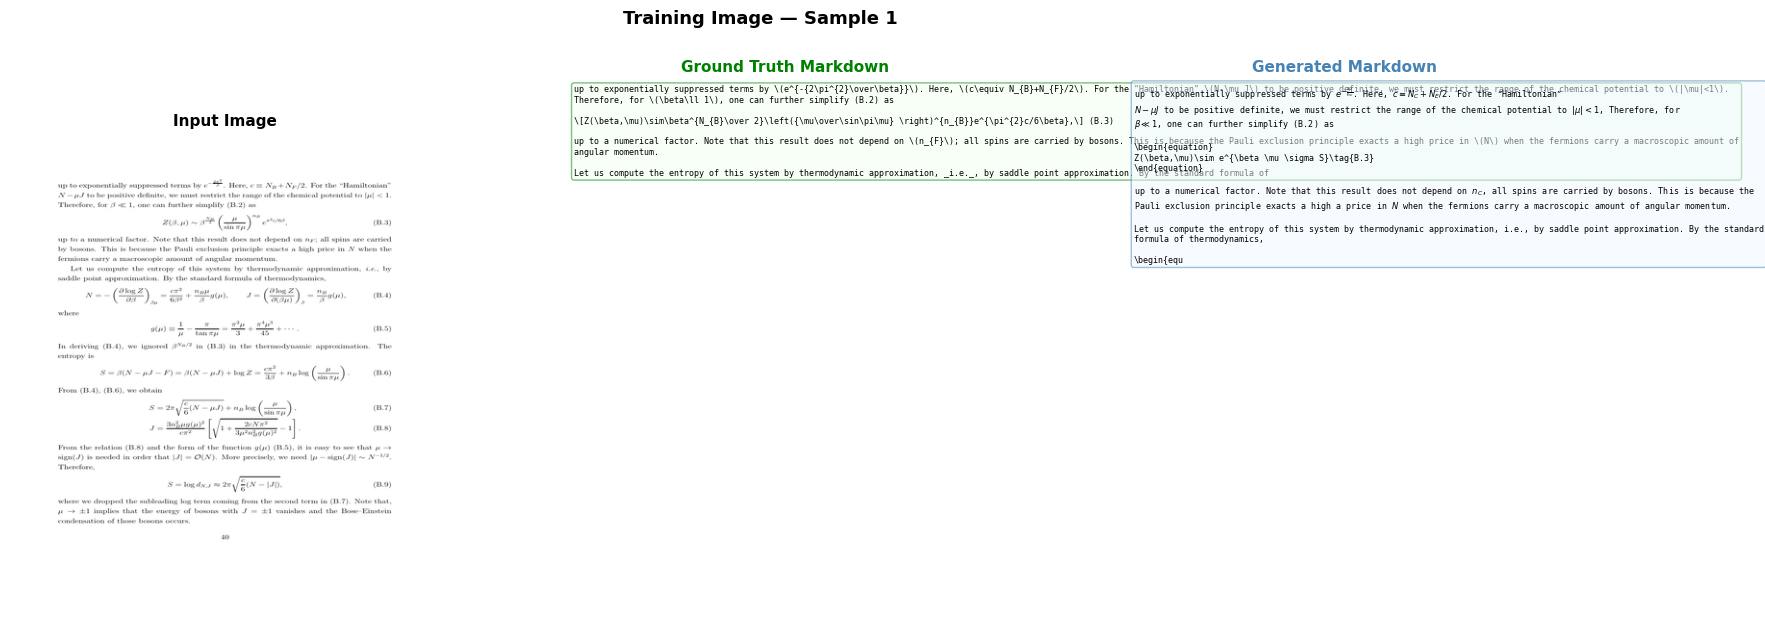

Saved: /kaggle/working/vlm_qlora/train_result_1.png


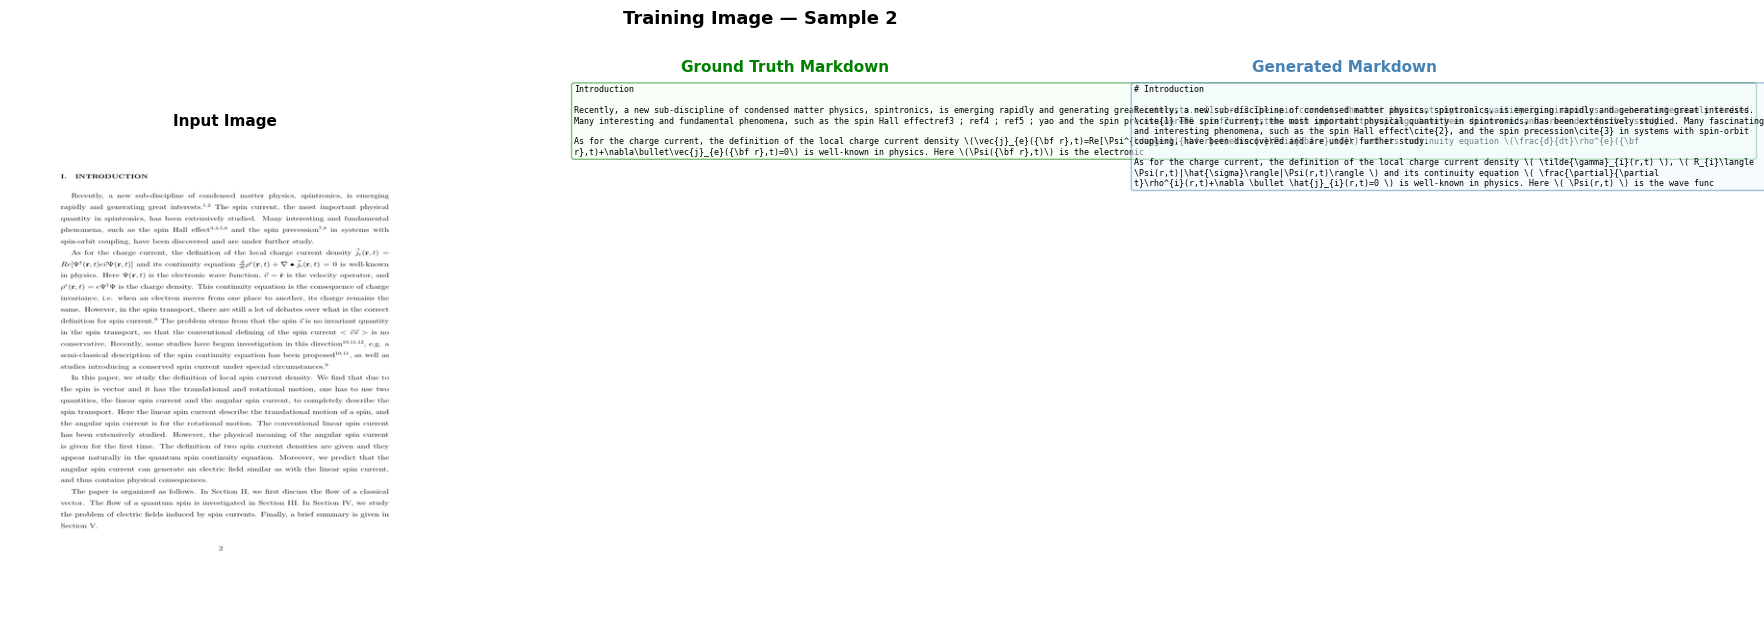

Saved: /kaggle/working/vlm_qlora/train_result_2.png


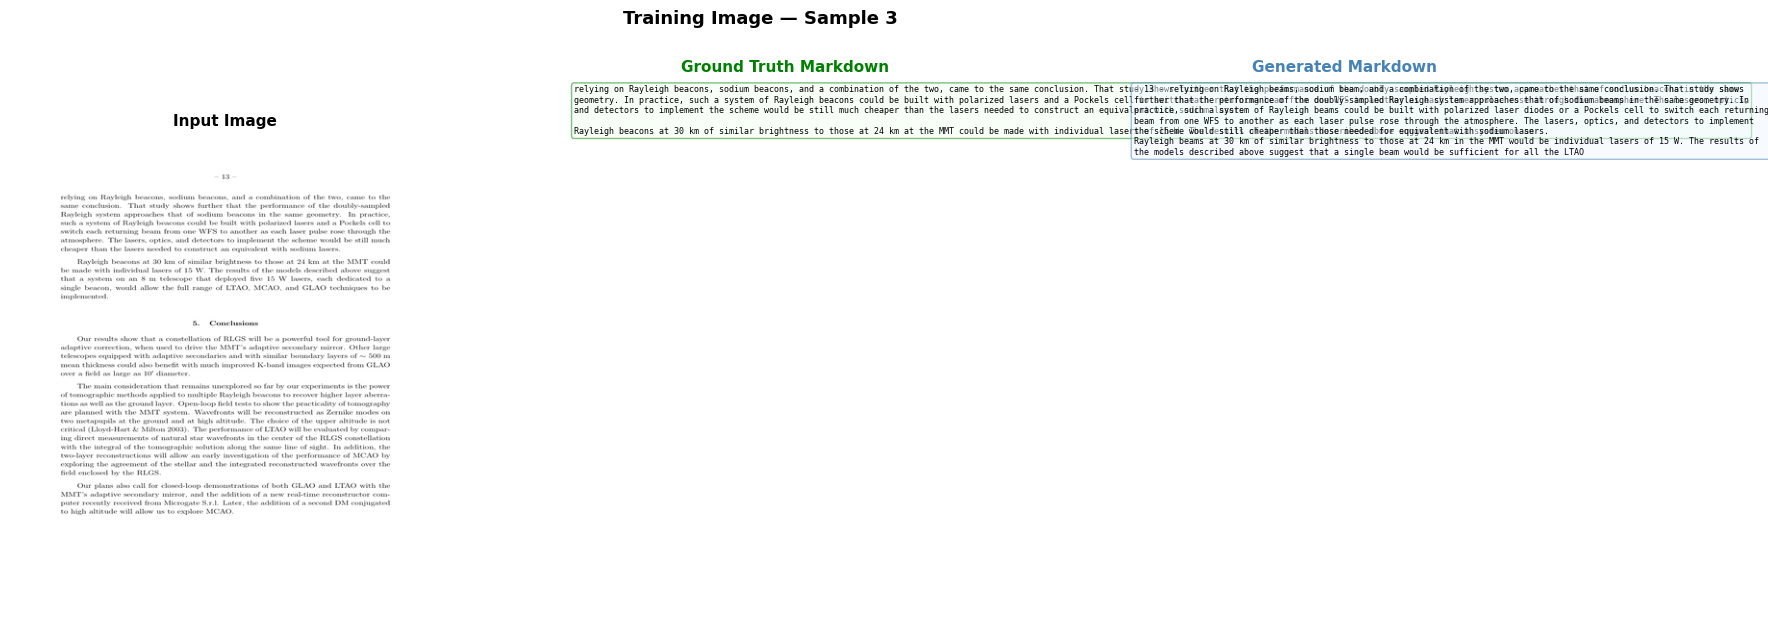

Saved: /kaggle/working/vlm_qlora/train_result_3.png

=== Unseen Images ===


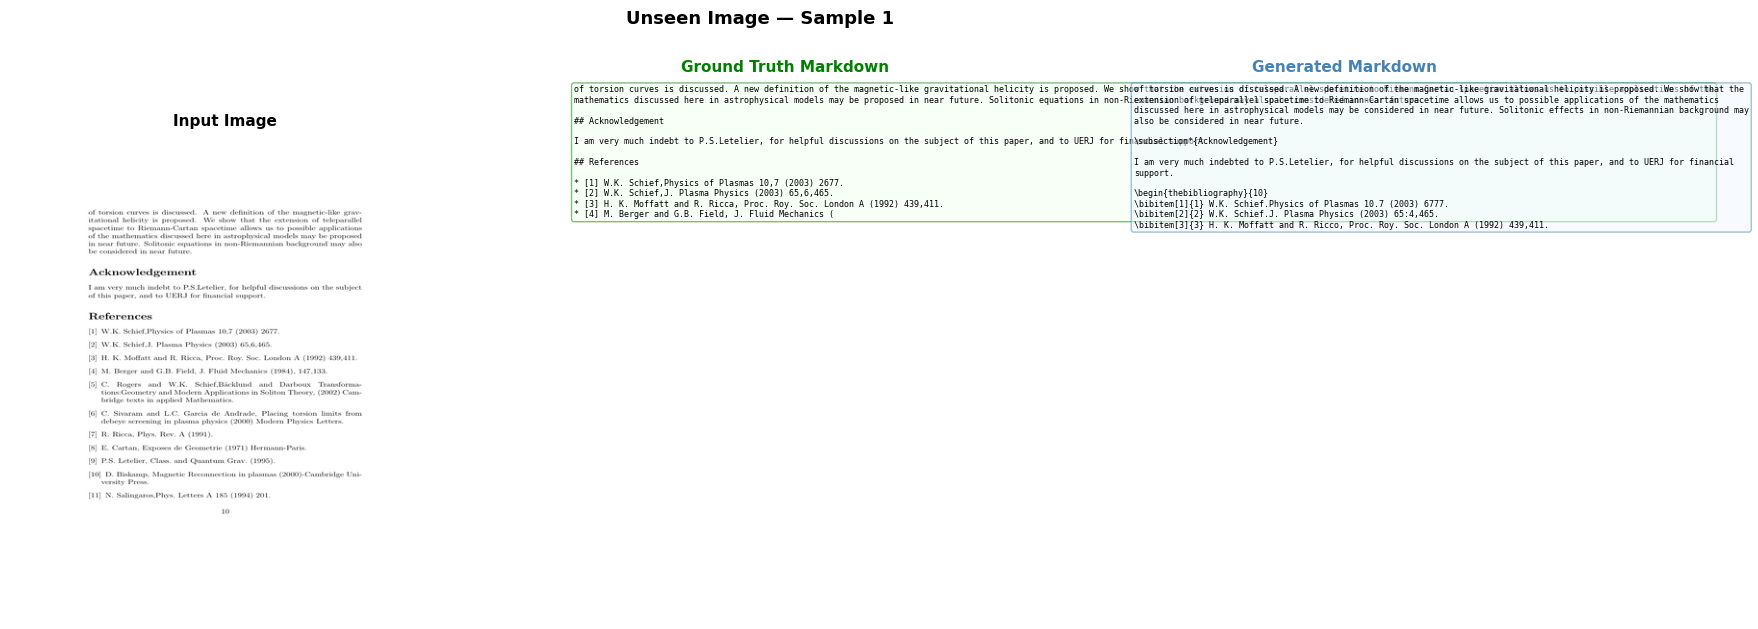

Saved: /kaggle/working/vlm_qlora/unseen_result_1.png


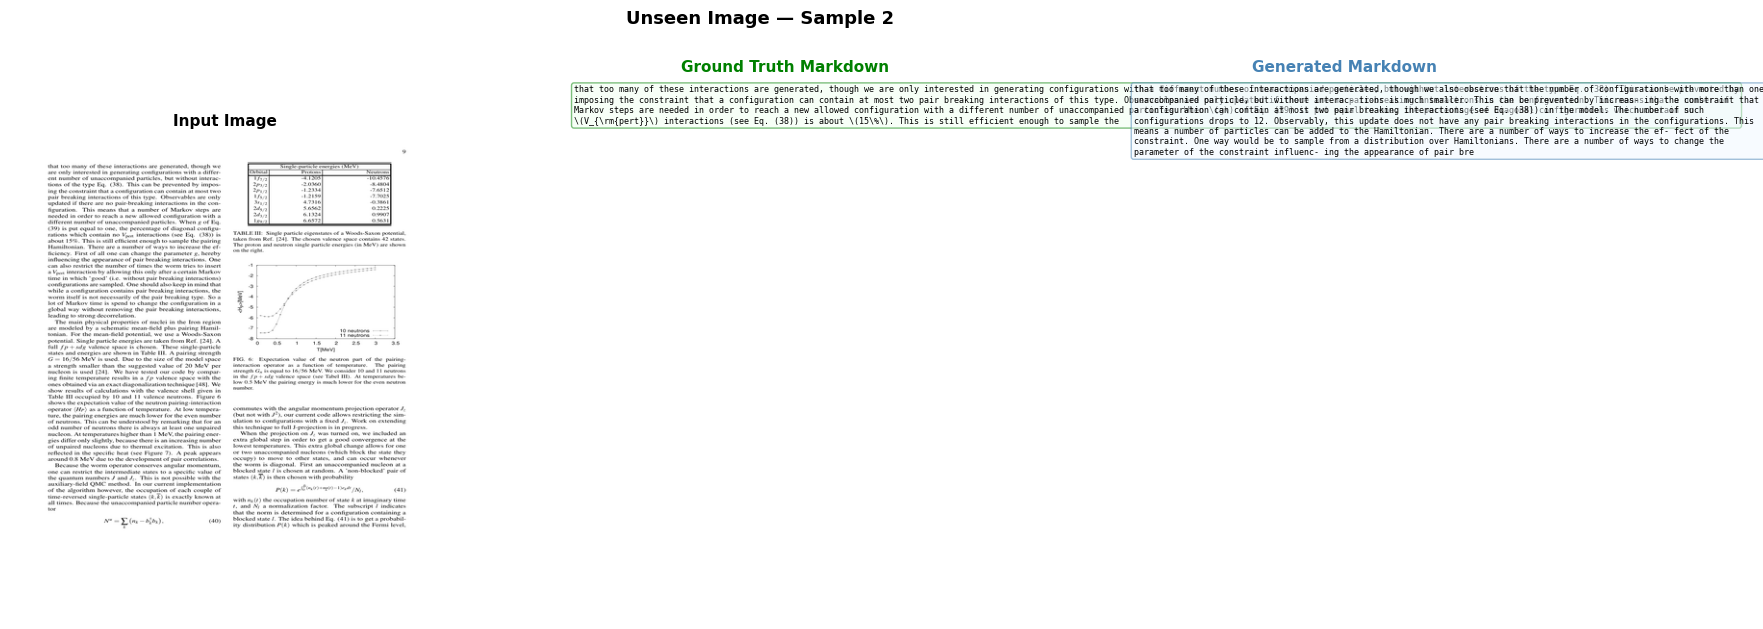

Saved: /kaggle/working/vlm_qlora/unseen_result_2.png


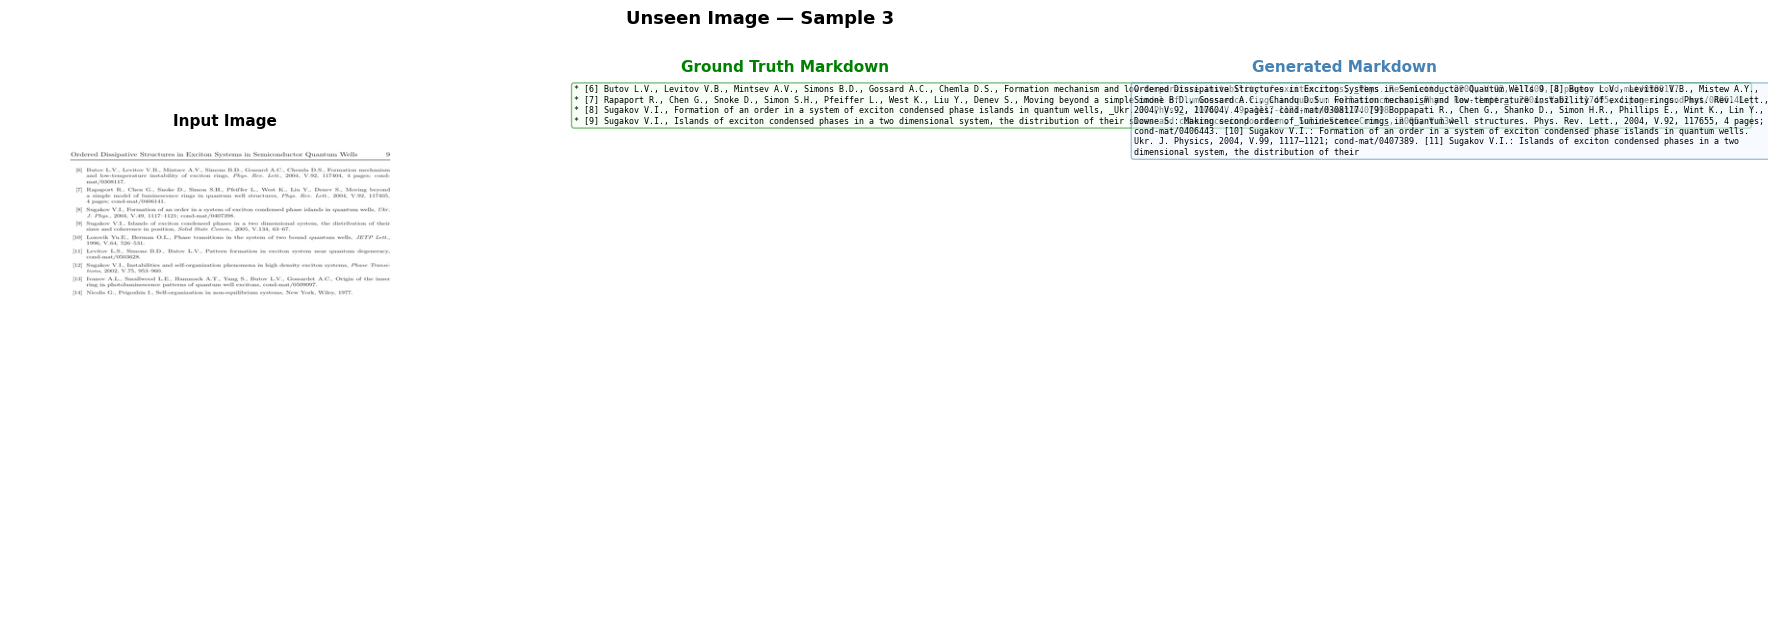

Saved: /kaggle/working/vlm_qlora/unseen_result_3.png


In [24]:
def display_results(samples, title_prefix, save_prefix):
    for idx, sample in enumerate(samples):
        pred = generate_markdown(sample, model, processor)
        gt   = sample["target"]

        fig = plt.figure(figsize=(20, 7))
        gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.3)

        # Image
        ax0 = fig.add_subplot(gs[0])
        ax0.imshow(sample["image"])
        ax0.set_title("Input Image", fontsize=11, fontweight="bold")
        ax0.axis("off")

        # Ground Truth
        ax1 = fig.add_subplot(gs[1])
        ax1.text(0.01, 0.99, gt[:800], va="top", ha="left", fontsize=6,
                 family="monospace", transform=ax1.transAxes, wrap=True,
                 bbox=dict(boxstyle="round", fc="#f0fff0", ec="green", alpha=0.5))
        ax1.set_title("Ground Truth Markdown", fontsize=11, fontweight="bold", color="green")
        ax1.axis("off")

        # Prediction
        ax2 = fig.add_subplot(gs[2])
        ax2.text(0.01, 0.99, pred[:800], va="top", ha="left", fontsize=6,
                 family="monospace", transform=ax2.transAxes, wrap=True,
                 bbox=dict(boxstyle="round", fc="#f0f8ff", ec="steelblue", alpha=0.5))
        ax2.set_title("Generated Markdown", fontsize=11, fontweight="bold", color="steelblue")
        ax2.axis("off")

        fig.suptitle(f"{title_prefix} — Sample {idx+1}", fontsize=13, fontweight="bold")
        fname = f"{CFG['output_dir']}/{save_prefix}_{idx+1}.png"
        plt.savefig(fname, dpi=120, bbox_inches="tight")
        plt.show()
        print(f"Saved: {fname}")
        print("=" * 60)


print("=== Training Images ===")
display_results(train_test_samples, "Training Image", "train_result")

print("\n=== Unseen Images ===")
display_results(unseen_samples, "Unseen Image", "unseen_result")

## Bonus — Zero-Shot vs Fine-Tuned Comparison

Loading base model for zero-shot comparison...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

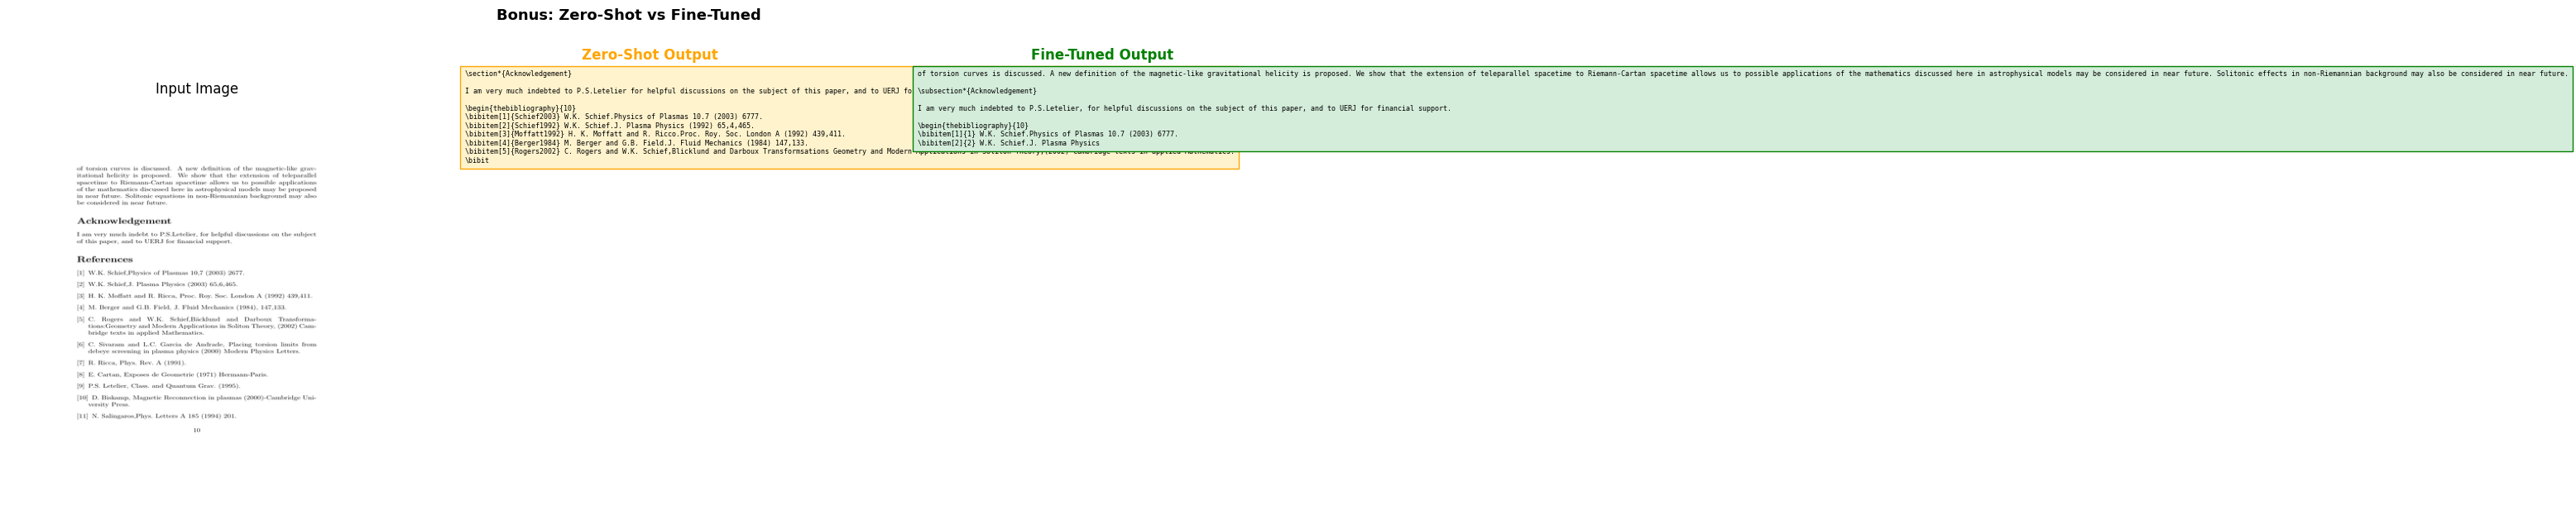

Comparison saved.


In [25]:
# Load the base model (no LoRA) for zero-shot comparison
print("Loading base model for zero-shot comparison...")
base_model = Qwen2VLForConditionalGeneration.from_pretrained(
    CFG["model_id"],
    quantization_config = bnb_config,
    device_map          = "auto",
    trust_remote_code   = True,
    torch_dtype         = torch.bfloat16,
)
base_model.eval()

sample = unseen_samples[0]
zero_shot_pred = generate_markdown(sample, base_model, processor)
fine_tuned_pred = generate_markdown(sample, model, processor)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
axes[0].imshow(sample["image"]); axes[0].set_title("Input Image"); axes[0].axis("off")
axes[1].text(0.01, 0.99, zero_shot_pred[:700], va="top", ha="left", fontsize=6,
             family="monospace", transform=axes[1].transAxes,
             bbox=dict(fc="#fff3cd", ec="orange"))
axes[1].set_title("Zero-Shot Output", color="orange", fontweight="bold"); axes[1].axis("off")
axes[2].text(0.01, 0.99, fine_tuned_pred[:700], va="top", ha="left", fontsize=6,
             family="monospace", transform=axes[2].transAxes,
             bbox=dict(fc="#d4edda", ec="green"))
axes[2].set_title("Fine-Tuned Output", color="green", fontweight="bold"); axes[2].axis("off")

plt.suptitle("Bonus: Zero-Shot vs Fine-Tuned", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/zeroshot_vs_finetuned.png", dpi=120)
plt.show()

del base_model; gc.collect(); torch.cuda.empty_cache()
print("Comparison saved.")

## Gradio App Deployment

In [26]:
import gradio as gr

def predict(image):
    """Gradio prediction function."""
    if image is None:
        return "Please upload an image."
    pil_img = Image.fromarray(image).convert("RGB").resize(
        (CFG["image_size"], CFG["image_size"]), Image.LANCZOS
    )
    sample = {"image": pil_img, "instruction": INSTRUCTION}
    return generate_markdown(sample, model, processor)


demo = gr.Interface(
    fn      = predict,
    inputs  = gr.Image(label="Upload Document Image"),
    outputs = gr.Textbox(label="Generated Markdown", lines=25),
    title   = "📄 Document → Markdown (Qwen2-VL + QLoRA)",
    description = (
        "Upload any document page image and the fine-tuned Vision Language Model "
        "will convert it into structured Markdown.\n"
        "Model: Qwen2-VL-2B-Instruct fine-tuned on Nougat dataset with QLoRA."
    ),
    examples = [
        [np.array(train_data[0]["image"])],
        [np.array(train_data[1]["image"])],
    ] if len(train_data) >= 2 else [],
    flagging_mode = "never",
)

demo.launch(
    share          = True,   # creates a public Gradio link
    server_name    = "0.0.0.0",
    server_port    = 7860,
    show_error     = True,
)


* Running on local URL:  http://0.0.0.0:7860
* Running on public URL: https://7394346701eae43bdd.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Summary

| Component | Details |
|---|---|
| **Model** | Qwen2-VL-2B-Instruct |
| **Fine-tuning** | QLoRA — 4-bit NF4 quantization |
| **LoRA Rank** | 16, alpha=32 |
| **Epochs** | 3 (with early stopping) |
| **Batch / Accum** | 1 / 8 (effective batch = 8) |
| **Learning Rate** | 1e-4 cosine schedule |
| **Dataset** | Nougat Training Dataset Example |
| **Split** | 80% train / 20% val |
| **Outputs** | Loss curves, ROUGE scores, per-sample comparison plots, Gradio app |
